In [ ]:
# Cell 0 — Imports & config
import sys, os
from pathlib import Path

# Locate project root by walking up until pyproject.toml is found
_cwd = Path(os.path.abspath(''))
PROJECT_ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'pyproject.toml').exists()),
    _cwd
)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import cv2

# ---- DATASET TOGGLE ----
# Set USE_BRATS_TEST = True  → use BraTS test NIfTI files (data/nii_test/)
# Set USE_BRATS_TEST = False → use real PPMR data (data/pmg_labels.csv)
USE_BRATS_TEST = True

# ---- USER CONFIG ----
if USE_BRATS_TEST:
    METADATA_CSV = PROJECT_ROOT / 'data' / 'nii_test_labels.csv'
    SUBJECT      = 'brats-001'
    SESSION      = 'seg'
    VOLUME_PATH  = None  # load from CSV
else:
    METADATA_CSV = PROJECT_ROOT / 'data' / 'pmg_labels.csv'
    SUBJECT      = 'sub-01'
    SESSION      = 'ses-001'
    VOLUME_PATH  = None  # set to the local NIfTI path for this subject/session

NEW_DATASET_DIR = PROJECT_ROOT / 'data' / 'new_dataset'
PPMR_DIR        = PROJECT_ROOT / 'data' / 'PPMR'
PPMR_PREPROCESSED_DIR = PROJECT_ROOT / 'data' / 'PPMR_default'

print(f'Project root : {PROJECT_ROOT}')
print(f'Metadata CSV : {METADATA_CSV}  (exists={METADATA_CSV.exists()})')
print(f'Active dataset: {"BraTS test" if USE_BRATS_TEST else "PPMR"}')

In [ ]:
# Cell 1 — Load volume
# Loads the NIfTI from the path in the metadata CSV for the chosen SUBJECT/SESSION.
# If VOLUME_PATH is set in Cell 0, that takes priority.

def load_volume(subject: str, session: str, volume_path=None, metadata_csv=None) -> np.ndarray | None:
    """Load NIfTI volume; returns (H, W, D) float64 array in RAS canonical orientation."""
    if volume_path is not None:
        p = Path(volume_path)
    else:
        if metadata_csv is None or not Path(metadata_csv).exists():
            print(f'Error: metadata CSV not found: {metadata_csv}')
            return None
        df = pd.read_csv(metadata_csv)
        row = df[(df['subject'] == subject) & (df['session'] == session)]
        if row.empty:
            print(f'Error: {subject}/{session} not found in CSV.')
            return None
        p = Path(row.iloc[0]['path'])
        if not p.is_absolute():
            p = PROJECT_ROOT / p  # CSV paths are relative to project root

    if not p.exists():
        print(f'Error: file not found: {p}')
        return None

    try:
        nii = nib.load(str(p))
        nii = nib.as_closest_canonical(nii)
        vol = nii.get_fdata()
        print(f'Loaded: {p}')
        print(f'Shape : {vol.shape}  dtype: {vol.dtype}')
        print(f'Range : [{vol.min():.2f}, {vol.max():.2f}]')
        return vol
    except Exception as exc:
        print(f'Error loading {p}: {exc}')
        return None


volume = load_volume(SUBJECT, SESSION, volume_path=VOLUME_PATH, metadata_csv=METADATA_CSV)

In [3]:
# Cell 2 — 3-plane view (axial / coronal / sagittal middle slices)

if volume is None:
    print('Volume not loaded — skipping cell.')
else:
    H, W, D = volume.shape
    mid_axial    = volume[:, :, D // 2]   # axis 2
    mid_coronal  = volume[:, W // 2, :]   # axis 1
    mid_sagittal = volume[H // 2, :, :]   # axis 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['Axial (middle)', 'Coronal (middle)', 'Sagittal (middle)']
    slices = [mid_axial, mid_coronal, mid_sagittal]

    for ax, sl, title in zip(axes, slices, titles):
        ax.imshow(np.rot90(sl), cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    fig.suptitle(f'{SUBJECT} / {SESSION} — 3-plane view', fontsize=13)
    plt.tight_layout()
    plt.show()

Volume not loaded — skipping cell.


In [4]:
# Cell 3 — Slice strip: 8 evenly-spaced axial slices in a 2x4 grid

if volume is None:
    print('Volume not loaded — skipping cell.')
else:
    D = volume.shape[2]
    indices = np.linspace(0, D - 1, 8, dtype=int)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, idx in zip(axes.flat, indices):
        ax.imshow(np.rot90(volume[:, :, idx]), cmap='gray')
        ax.set_title(f'Slice {idx}')
        ax.axis('off')

    fig.suptitle(f'{SUBJECT} / {SESSION} — Axial slice strip (8 evenly spaced)', fontsize=13)
    plt.tight_layout()
    plt.show()

Volume not loaded — skipping cell.


In [5]:
# Cell 4 — Preprocessing comparison
# Shows raw axial slice + 5 preprocessing presets in a 2x3 grid.

try:
    from src.main.configurable_pipeline import preprocess_image
    from src.config.preprocessing_config import (
        PreprocessingConfig, CLAHEConfig, BilateralFilterConfig, CannyConfig, NormalizationConfig
    )

    if volume is None:
        print('Volume not loaded — skipping cell.')
    else:
        D = volume.shape[2]
        mid_idx = D // 2
        raw_slice = volume[:, :, mid_idx]

        # Normalize to uint8 for pipeline input
        v_min, v_max = raw_slice.min(), raw_slice.max()
        if v_max > v_min:
            raw_uint8 = ((raw_slice - v_min) / (v_max - v_min) * 255).astype(np.uint8)
        else:
            raw_uint8 = np.zeros_like(raw_slice, dtype=np.uint8)

        # Define 5 presets
        presets = [
            ('min_max only',  PreprocessingConfig()),
            ('clahe',         PreprocessingConfig(clahe=CLAHEConfig(clip_limit=2.0))),
            ('bilateral',     PreprocessingConfig(bilateral=BilateralFilterConfig())),
            ('clahe+bilateral', PreprocessingConfig(
                clahe=CLAHEConfig(clip_limit=2.0),
                bilateral=BilateralFilterConfig()
            )),
            ('zscore',        PreprocessingConfig(normalization=NormalizationConfig(method='zscore'))),
        ]

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes[0, 0].imshow(np.rot90(raw_uint8), cmap='gray')
        axes[0, 0].set_title(f'Raw (slice {mid_idx})')
        axes[0, 0].axis('off')

        flat_axes = list(axes.flat)[1:]  # remaining 5 axes
        for ax, (name, cfg) in zip(flat_axes, presets):
            try:
                result, _ = preprocess_image(raw_uint8.copy(), cfg)
                disp = (np.clip(result, 0, 1) * 255).astype(np.uint8) if result.dtype != np.uint8 else result
                ax.imshow(np.rot90(disp), cmap='gray')
            except Exception as exc:
                ax.text(0.5, 0.5, f'Error:\n{exc}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(name)
            ax.axis('off')

        fig.suptitle(f'{SUBJECT} / {SESSION} — Preprocessing comparison', fontsize=13)
        plt.tight_layout()
        plt.show()

except ImportError as exc:
    print(f'Could not import preprocessing modules: {exc}')
    print('Run from the project root or ensure src/ is on sys.path.')

Volume not loaded — skipping cell.


/var/folders/m7/bb8y972s4gl6rtt12h15d9mw0000gn/T/ipykernel_56065/3487216350.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


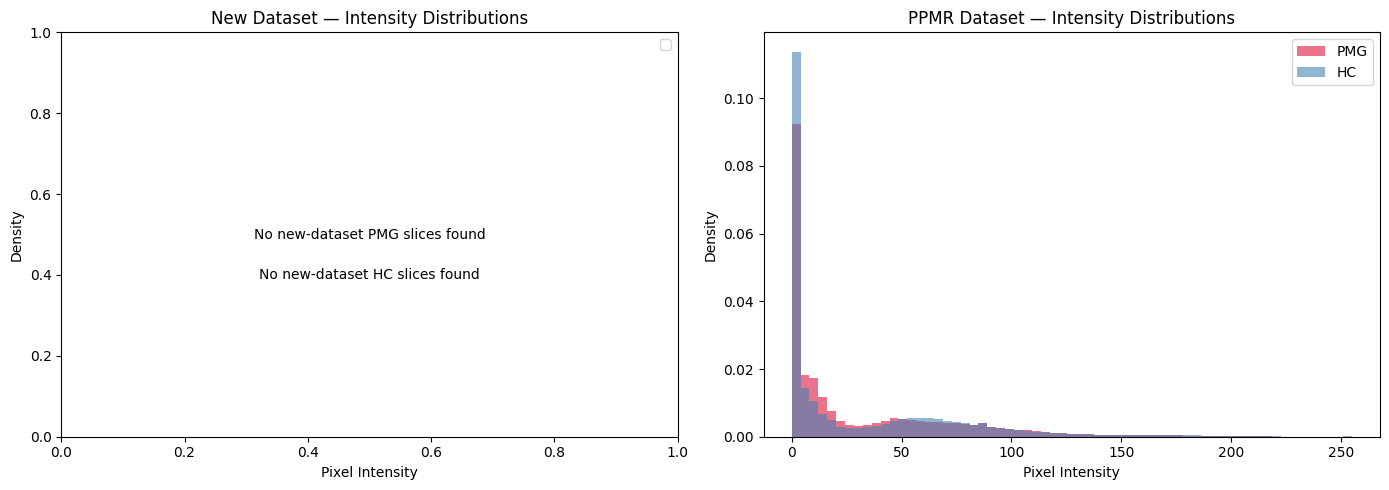

In [6]:
# Cell 5 — Intensity histogram comparison
# Compares pixel intensity distributions between:
#   New dataset PMG vs HC (from NEW_DATASET_DIR)
#   PPMR PMG vs HC      (from PPMR_DIR)

SAMPLE_SIZE = 500
rng = np.random.default_rng(42)

def _sample_intensities(folder: Path, n: int, rng) -> np.ndarray | None:
    """Randomly sample n JPEG files from folder (recursive) and collect all pixel values."""
    if not folder.exists():
        return None
    files = sorted(folder.rglob('*.jpg')) + sorted(folder.rglob('*.jpeg'))
    if not files:
        return None
    chosen = rng.choice(files, size=min(n, len(files)), replace=False)
    pixels = []
    for f in chosen:
        try:
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                pixels.append(img.ravel())
        except Exception:
            pass
    return np.concatenate(pixels) if pixels else None

new_pmg_dir  = Path(NEW_DATASET_DIR) / 'PMGcases'
new_hc_dir   = Path(NEW_DATASET_DIR) / 'controlcases'
ppmr_pmg_dir = Path(PPMR_DIR) / 'PMGstudycaseslabelled'
ppmr_hc_dir  = Path(PPMR_DIR) / 'PMGControlsEditedDec2021'

new_pmg  = _sample_intensities(new_pmg_dir,  SAMPLE_SIZE, rng)
new_hc   = _sample_intensities(new_hc_dir,   SAMPLE_SIZE, rng)
ppmr_pmg = _sample_intensities(ppmr_pmg_dir, SAMPLE_SIZE, rng)
ppmr_hc  = _sample_intensities(ppmr_hc_dir,  SAMPLE_SIZE, rng)

bins = np.linspace(0, 255, 64)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# New dataset
ax = axes[0]
ax.set_title('New Dataset — Intensity Distributions')
if new_pmg is not None:
    ax.hist(new_pmg,  bins=bins, density=True, alpha=0.6, label='PMG',  color='crimson')
else:
    ax.text(0.5, 0.5, 'No new-dataset PMG slices found', ha='center', va='center', transform=ax.transAxes)
if new_hc is not None:
    ax.hist(new_hc,   bins=bins, density=True, alpha=0.6, label='HC',   color='steelblue')
else:
    ax.text(0.5, 0.4, 'No new-dataset HC slices found',  ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.legend()

# PPMR dataset
ax = axes[1]
ax.set_title('PPMR Dataset — Intensity Distributions')
if ppmr_pmg is not None:
    ax.hist(ppmr_pmg, bins=bins, density=True, alpha=0.6, label='PMG',  color='crimson')
else:
    ax.text(0.5, 0.5, 'No PPMR PMG slices found', ha='center', va='center', transform=ax.transAxes)
if ppmr_hc is not None:
    ax.hist(ppmr_hc,  bins=bins, density=True, alpha=0.6, label='HC',   color='steelblue')
else:
    ax.text(0.5, 0.4, 'No PPMR HC slices found',  ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Cell 6 — Dataset statistics
# Per-class counts from CSV, slices-per-subject table, and new_dataset slice counts.

csv_path = Path(METADATA_CSV)
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print('=== Metadata CSV ===' )
    print(f'Total rows: {len(df)}')
    print()
    print('Per-class counts:')
    print(df['label'].value_counts().to_string())
    print()
    print('Rows per subject:')
    print(df.groupby('subject')['label'].value_counts().unstack(fill_value=0).to_string())
else:
    print(f'Metadata CSV not found: {csv_path}')

print()

# New dataset slice counts
new_dir = Path(NEW_DATASET_DIR)
if new_dir.exists():
    pmg_slices = list((new_dir / 'PMGcases').rglob('*.jpg')) if (new_dir / 'PMGcases').exists() else []
    hc_slices  = list((new_dir / 'controlcases').rglob('*.jpg')) if (new_dir / 'controlcases').exists() else []
    print(f'=== New Dataset ({NEW_DATASET_DIR}) ===')
    print(f'PMG slices      : {len(pmg_slices)}')
    print(f'HC  slices      : {len(hc_slices)}')
    print(f'Total slices    : {len(pmg_slices) + len(hc_slices)}')

    # Per-subject slice counts
    def _count_by_subject(slices):
        counts = {}
        for p in slices:
            # session_id is the first field: sub01-ses001_042_0_1.jpg -> sub01-ses001
            sess_id = p.stem.split('_')[0]
            counts[sess_id] = counts.get(sess_id, 0) + 1
        return counts

    pmg_counts = _count_by_subject(pmg_slices)
    hc_counts  = _count_by_subject(hc_slices)

    rows = []
    for k, v in sorted(pmg_counts.items()):
        rows.append({'session_id': k, 'class': 'PMG', 'n_slices': v})
    for k, v in sorted(hc_counts.items()):
        rows.append({'session_id': k, 'class': 'HC',  'n_slices': v})

    if rows:
        print()
        print('Slices per subject (new dataset):')
        print(pd.DataFrame(rows).to_string(index=False))
else:
    print(f'New dataset directory not found: {new_dir}')
    print('Run `uv run slice-volumes` first to generate the slices.')

Metadata CSV not found: ../data/pmg_labels.csv

New dataset directory not found: ../data/new_dataset
Run `uv run slice-volumes` first to generate the slices.
